# Data Mining Project: Startups Success
**Objective:** Can Twitter activity and engagement predict startup success?



## 1. The Business Case: Predicting Startup Success

Early-stage investors face a fundamental problem: at the **INCEPTION** stage, startups have no revenue, no product-market fit, and no track record. How do you decide who to fund?

One hypothesis is that **Twitter traction** (how actively a startup tweets, and how much engagement it generates) is an indicator for true acitvity momentum. If the market is talking about you, maybe you are onto something.

In this project we ask: **can Twitter activity and engagement metrics predict whether a startup successfully moves from Inception to the next funding stage?**

The target variable is `stage_success` (1 = advanced to next stage, 0 = did not).

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 3. Load & Inspect the Raw Data

We start by loading the raw dataset and understanding its structure before touching anything.

In [2]:
df_raw = pd.read_csv("startup_traction.csv", index_col=0)

print(f"Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Shape: (700, 29)


,name,country,city,web,PIC,stage_order,stage_name,tweet_count,tweet_length,tweet_rate,...,reply_ratio,reply_rate,like_count,like_rate,like_ratio,quote_count,quote_rate,quote_ratio,engagement_ratio,stage_success
669,N.P.T. S.R.L.,ITALY,VALSAMOGGIA BO,NaN,917744355,1,INCEPTION,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1236,ADVANCED MATERIALS SRL,ITALY,LAIVES,http://www.airlite.eu,935677812,1,INCEPTION,636.0,170.550314,1.121693,...,0.031447,0.035273,547.0,0.964727,0.860063,547.0,0.964727,0.860063,71.408805,0
1643,GRAPHENEA SA,SPAIN,SAN SEBASTIAN GUIPUZCOA,http://www.graphenea.com,971995582,1,INCEPTION,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
331,CROIVALVE LIMITED,IRELAND,DUBLIN,http://www.croivalve.com,909573463,1,INCEPTION,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
614,OU COGNUSE,ESTONIA,TALLINN,http://www.cognuse.com,916757671,1,INCEPTION,126.0,137.015873,0.049901,...,0.031746,0.001584,96.0,0.038020,0.761905,96.0,0.038020,0.761905,5.880952,0


In [3]:
# Data types 
df_raw.dtypes

name                        object
country                     object
city                        object
web                         object
PIC                          int64
stage_order                  int64
stage_name                  object
tweet_count                float64
tweet_length               float64
tweet_rate                 float64
original_ratio             float64
retweeted_ratio            float64
replied_to_ratio           float64
quoted_ratio               float64
quoted_replied_to_ratio    float64
retweet_count              float64
retweet_ratio              float64
retweet_rate               float64
reply_count                float64
reply_ratio                float64
reply_rate                 float64
like_count                 float64
like_rate                  float64
like_ratio                 float64
quote_count                float64
quote_rate                 float64
quote_ratio                float64
engagement_ratio           float64
stage_success       

In [4]:
# Null dara
df_raw.isnull().sum()

name                         0
country                      0
city                         0
web                         51
PIC                          0
stage_order                  0
stage_name                   0
tweet_count                391
tweet_length               391
tweet_rate                 391
original_ratio             393
retweeted_ratio            411
replied_to_ratio           457
quoted_ratio               441
quoted_replied_to_ratio    682
retweet_count              391
retweet_ratio              391
retweet_rate               391
reply_count                391
reply_ratio                391
reply_rate                 391
like_count                 391
like_rate                  391
like_ratio                 391
quote_count                391
quote_rate                 391
quote_ratio                391
engagement_ratio           391
stage_success                0
dtype: int64

In [5]:
# Target variable distribution
print(" Target Variable:", df_raw['stage_success'].value_counts())

print(f"Succesfull startups: {df_raw['stage_success'].mean()*100:.1f}%")

 Target Variable: stage_success
0    589
1    111
Name: count, dtype: int64
Succesfull startups: 15.9%


In [49]:
# Understand the missing pattern: are rows missing ALL Twitter data, or just some columns?
twitter_cols = ['tweet_count', 'tweet_rate', 'retweet_count', 'like_count', 'engagement_ratio']
no_twitter_mask = df_raw['tweet_count'].isnull()

print(f"Rows with NO Twitter data at all: {no_twitter_mask.sum()}")
print(f"Rows WITH Twitter data:           {(~no_twitter_mask).sum()}")
print()
print("Success rate: WITH Twitter:    ", df_raw[~no_twitter_mask]['stage_success'].mean().round(3))
print("Success rate:WITHOUT Twitter: ", df_raw[no_twitter_mask]['stage_success'].mean().round(3))

Rows with NO Twitter data at all: 391
Rows WITH Twitter data:           309

Success rate: WITH Twitter:     0.278
Success rate:WITHOUT Twitter:  0.064


**Key observation:** 391 out of 700 startups (55.9%) have no Twitter presence at all. Thismeans that these startups don't have or don't use Twitter account. Their success rate (6.4%) is dramatically lower than those who are active on Twitter (27.8%), which aldready shows that the vaiable has_twitter is itself an important variable.

## 4. Data Cleaning

We will perform the following to prepare our data:

1. **Drop irrelevant columns** : `web`, `PIC`, `stage_order`, `stage_name` because they don't add any predictive value for the model.
2. **Fill Twitter NaNs with 0**: for startups with no Twitter presence since 0 is the correct value (as they had zero tweets), not a missing value.
3. **Add `has_twitter` binary flag** : captures the structural difference between active and not active startups.

In [7]:
df = df_raw.copy()

# 1. Drop columns that are irrelevant or nearly empty
drop_cols = ['web', 'PIC', 'stage_order', 'stage_name']
df = df.drop(columns=drop_cols)
print(f"Shape after dropping irrelevant columns: {df.shape}")

Shape after dropping irrelevant columns: (700, 25)


In [8]:
# 2. Add binary Twitter presence values 
df['has_twitter'] = (~df['tweet_count'].isnull()).astype(int)
print("has_twitter value counts:")
print(df['has_twitter'].value_counts())

has_twitter value counts:
has_twitter
0    391
1    309
Name: count, dtype: int64


In [9]:
# 3. Fill all remaining NaNs with 0 because startups without twitter their activity is zero and for startups in twitter with isolated NaNs in zero is correct (for example no replies, comments...)
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df[numeric_cols] = df[numeric_cols].fillna(0)

df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [10]:
# Final cleaned dataset 
print(f"Final shape: {df.shape}")
df.describe()

Final shape: (700, 26)


,tweet_count,tweet_length,tweet_rate,original_ratio,retweeted_ratio,replied_to_ratio,quoted_ratio,quoted_replied_to_ratio,retweet_count,retweet_ratio,...,reply_rate,like_count,like_rate,like_ratio,quote_count,quote_rate,quote_ratio,engagement_ratio,stage_success,has_twitter
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,7.000000e+02,700.000000,...,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,365.161429,72.783180,0.285777,0.275466,0.113375,0.028091,0.024444,0.000053,1.010491e+04,11.543896,...,0.025518,691.714286,0.645908,0.901246,691.714286,0.645908,0.901246,12.520301,0.158571,0.441429
std,1705.114111,86.418634,1.192321,0.344637,0.184808,0.071819,0.051702,0.000503,1.568470e+05,98.082280,...,0.120681,4325.509346,4.626638,2.193602,4325.509346,4.626638,2.193602,98.319760,0.365537,0.496913
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,162.250000,153.129324,0.186677,0.600000,0.181856,0.023222,0.032258,0.000000,4.187500e+02,2.017838,...,0.008707,206.500000,0.196940,1.274555,206.500000,0.196940,1.274555,4.227948,0.000000,1.000000
max,32317.000000,290.000000,24.631860,1.000000,1.000000,0.716749,0.666667,0.009709,4.116868e+06,2295.808511,...,2.000000,84947.000000,97.000000,39.148528,84947.000000,97.000000,39.148528,2300.744681,1.000000,1.000000


In [11]:
# Save the cleaned dataset for modeling
df.to_csv("outputs/cleaned_data.csv")

## 5. Exploratory Data Analysis 

With the data clean, we can now explore relationships between Twitter variables and startup success. We conduct EDA in four steps:

**5.1** Twitter presence vs. success (full dataset)

**5.2** Correlation analysis (Twitter-active startups)

**5.3** Scatter plots and distribution plots for key variables
**5.4** Distribution Plots: Successful vs Not Successful

 For correlations and distributions, we will use only the startups that use twitter. Including the 391 NA would shift the variance and impact our results.

In [12]:
# Separate Twitter active startups for EDA
df_tw = df[df['has_twitter'] == 1].copy()

# Feature columns (all except name/city/country and target)
feature_cols = [c for c in df_tw.columns if c not in ['name', 'country', 'city', 'stage_success', 'has_twitter']]

### 5.1 Twitter Presence vs. Success

Before any feature analysis, the most striking finding is structural: **simply having a Twitter account predicts success**.

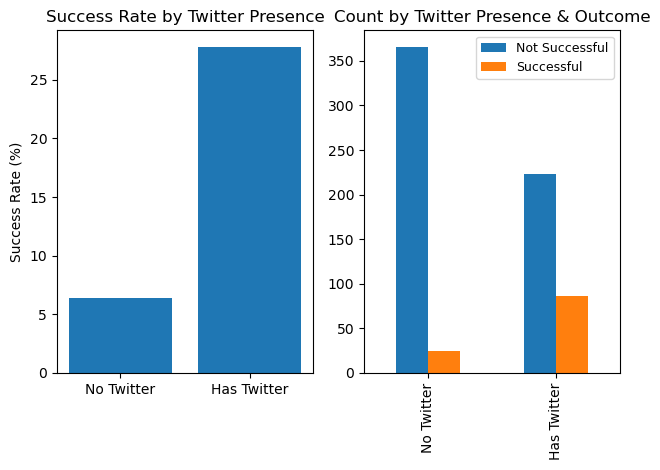

In [13]:
# Success rate by Twitter presence
twitter_success = df.groupby('has_twitter')['stage_success'].mean().reset_index()
twitter_success['label'] = ['No Twitter', 'Has Twitter']
twitter_counts = df.groupby(['has_twitter', 'stage_success']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2)

# Left: success rate bar
axes[0].bar(twitter_success['label'], twitter_success['stage_success'] * 100)
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_title('Success Rate by Twitter Presence')

# Right: stacked count
tw_pivot = twitter_counts.pivot(index='has_twitter', columns='stage_success', values='count').fillna(0)
tw_pivot.index = ['No Twitter', 'Has Twitter']
tw_pivot.columns = ['Not Successful', 'Successful']
tw_pivot.plot(kind='bar', ax=axes[1])
axes[1].set_title('Count by Twitter Presence & Outcome')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

 Startups with a Twitter account succeed at 27.8% and those without one only 6.4% . This difference suggests that `has_twitter` will be an important feature for our model, even before considering what the startups actually tweet.

### 5.2 Correlation Analysis

Now we'll compute the correlations between all Twitter features and `stage_success` to identify the strongest predictors variables.

In [14]:
# Correlation of each feature with stage_success
corr_matrix = df_tw[feature_cols + ['stage_success']].corr()
corr_with_success = corr_matrix['stage_success'].drop('stage_success').sort_values(ascending=False)

print("Correlations with stage_success")
print(corr_with_success.to_string())

Correlations with stage_success
reply_rate                 0.098136
retweet_ratio              0.083810
engagement_ratio           0.082612
retweeted_ratio            0.077637
tweet_rate                 0.057565
replied_to_ratio           0.051061
quote_rate                 0.050159
like_rate                  0.050159
reply_ratio                0.011633
retweet_rate              -0.011614
quoted_replied_to_ratio   -0.026764
reply_count               -0.029301
retweet_count             -0.036562
tweet_count               -0.042534
original_ratio            -0.046664
like_ratio                -0.055556
quote_ratio               -0.055556
like_count                -0.078031
quote_count               -0.078031
quoted_ratio              -0.151656
tweet_length              -0.306081


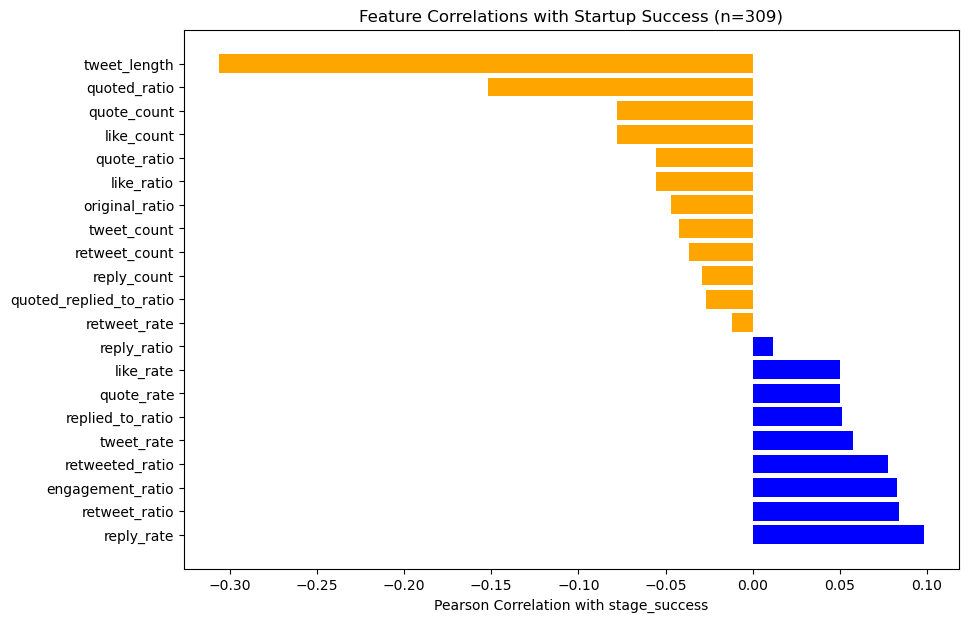

In [15]:

# Correlation bar chart 
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['blue' if v >= 0 else 'orange' for v in corr_with_success]

ax.barh(corr_with_success.index, corr_with_success.values, color=colors)
ax.set_xlabel('Pearson Correlation with stage_success')
ax.set_title('Feature Correlations with Startup Success (n=309)')

plt.show()

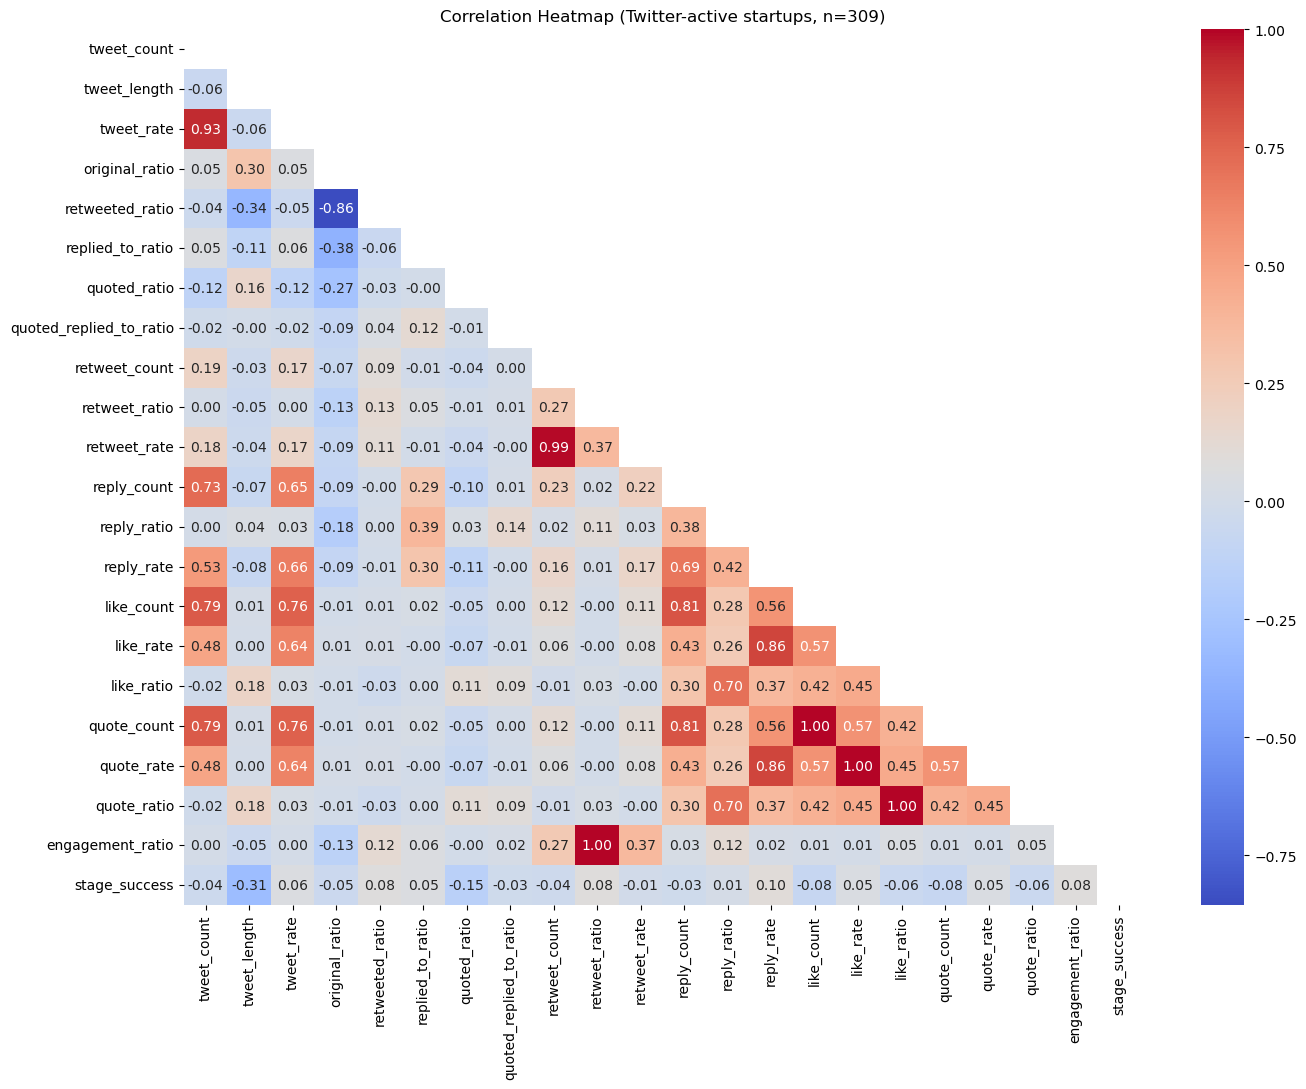

In [16]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm')
ax.set_title('Correlation Heatmap (Twitter-active startups, n=309)')

plt.tight_layout()
plt.show()

The strongest positive predictors are engagement-based: `reply_rate`, `retweet_ratio`, and `engagement_ratio`. These capture how much other people are reacting to a startup's content, which is a more meaningful signal than just posting activity.

The strongest negative predictor is `tweet_length` (r=−0.306). The most powerful individual feature in the dataset. Startups that write shorter tweets tend to be more successful, which may reflect clearer communication and stronger positioning.

`quoted_ratio` is also negative (r=−0.152): startups that quote other accounts a lot tend to perform worse, possibly because they are reacting rather than leading the conversation.

Finally, raw count variables like `like_count`, `quote_count`, and `retweet_count` are highly correlated with their rate/ratio versions. We drop the counts and keep the normalised versions to avoid multicollinearity in the model.

### 5.3 Scatter Plots: Key Variables 

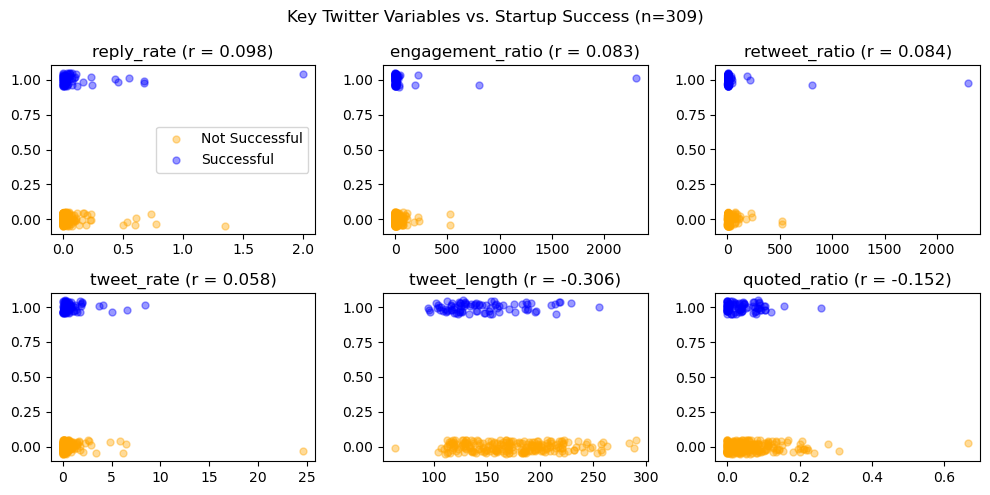

In [17]:
# key variables and stage_success
plot_vars = ['reply_rate', 'engagement_ratio', 'retweet_ratio', 'tweet_rate', 'tweet_length', 'quoted_ratio']

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    ax = axes[i]
    for success, label, color in [(0, 'Not Successful','orange'), (1, 'Successful', 'blue')]:
        subset = df_tw[df_tw['stage_success'] == success]
        jitter = np.random.uniform(-0.05, 0.05, len(subset))
        ax.scatter(subset[var], success + jitter, alpha=0.4, s=25, color=color, label=label)
    r = df_tw[[var, 'stage_success']].corr().iloc[0, 1]
    ax.set_title(f'{var} (r = {r:.3f})')
    if i == 0:
        ax.legend()

plt.suptitle('Key Twitter Variables vs. Startup Success (n=309)')
plt.tight_layout()
plt.show()

### 5.4 Distribution Plots: Successful vs Not Successful

KDE plots let us compare how the *shape* of each variable's distribution differs between successful and unsuccessful startups.

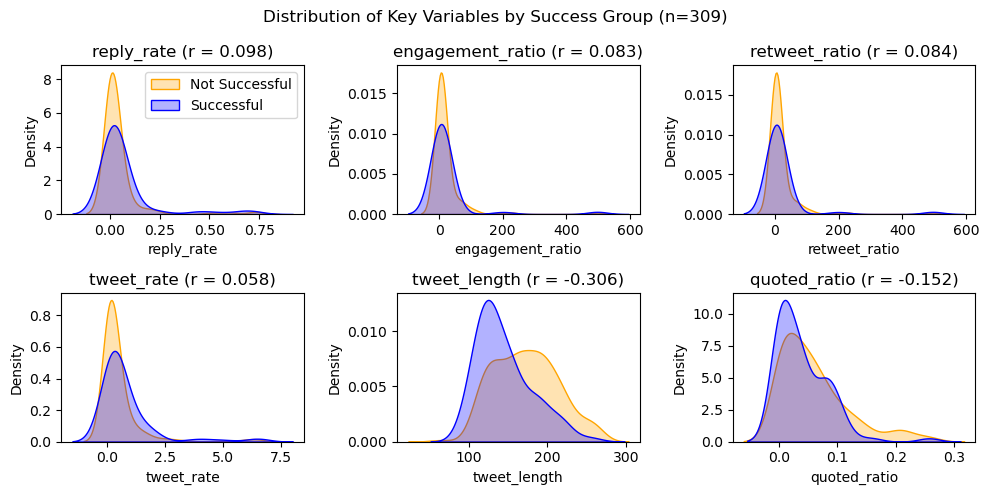

In [18]:
# Distribution of key variables by success group
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    ax = axes[i]
    cap = df_tw[var].quantile(0.99)
    for success, label, color in [(0, 'Not Successful', 'orange'), (1, 'Successful', 'blue')]:
        subset = df_tw[df_tw['stage_success'] == success][var].clip(upper=cap)
        sns.kdeplot(subset, ax=ax, label=label, color=color, fill=True, alpha=0.3)
    r = df_tw[[var, 'stage_success']].corr().iloc[0, 1]
    ax.set_title(f'{var} (r = {r:.3f})')
    if i == 0:
        ax.legend()

plt.suptitle('Distribution of Key Variables by Success Group (n=309)')
plt.tight_layout()
plt.show()

The `tweet_length` distribution is the clearest: successful startups are visibly shifted towards shorter tweets. For engagement metrics like `reply_rate` and `retweet_ratio`, successful startups show a heavier right tail. More extreme engagement values appear more often in the successful group.

## 6. Summary of Key Findings

This section consolidates the EDA insights and produces the final feature recommendations for the modeling phase.

In [19]:
# Summary table: correlation with stage_success, ranked
summary = corr_with_success.reset_index()
summary.columns = ['Feature', 'Correlation']
summary['Direction'] = summary['Correlation'].apply(
    lambda x: 'Positive' if x > 0.04 else ('Negative' if x < -0.04 else 'Weak')
)
display(summary)

,Feature,Correlation,Direction
0,reply_rate,0.098136,Positive
1,retweet_ratio,0.083810,Positive
2,engagement_ratio,0.082612,Positive
3,retweeted_ratio,0.077637,Positive
4,tweet_rate,0.057565,Positive
5,replied_to_ratio,0.051061,Positive
6,quote_rate,0.050159,Positive
7,like_rate,0.050159,Positive
8,reply_ratio,0.011633,Weak
9,retweet_rate,-0.011614,Weak


**Recommended Features for Modeling**

Include: strong positive predictors: `reply_rate`, `retweet_ratio`, `engagement_ratio`, `retweeted_ratio`, `tweet_rate`

Include: strong negative predictors: `tweet_length`, `quoted_ratio`

Include: structural signal: `has_twitter` (binary flag, 4x higher success rate)

Exclude: redundant raw counts, correlated with their rate/ratio versions: `like_count`, `quote_count`, `retweet_count`, `reply_count`

Exclude: near-zero variance or very weak correlation: `tweet_count`, `original_ratio`, `like_ratio`

Use the dataset cleaned_data that has 700 rows, 26 columns, no missing values, ready for train/test split.

## 7. Load the Cleaned Dataset

We load the cleaned dataset produced by EDA . It has 700 rows, no missing values, and includes the engineered `has_twitter` flag.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score

In [21]:
df = pd.read_csv("outputs/cleaned_data.csv", index_col=0)

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: (700, 26)
Missing values: 0


,name,country,city,tweet_count,tweet_length,tweet_rate,original_ratio,retweeted_ratio,replied_to_ratio,quoted_ratio,...,reply_rate,like_count,like_rate,like_ratio,quote_count,quote_rate,quote_ratio,engagement_ratio,stage_success,has_twitter
669,N.P.T. S.R.L.,ITALY,VALSAMOGGIA BO,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0
1236,ADVANCED MATERIALS SRL,ITALY,LAIVES,636.0,170.550314,1.121693,0.630503,0.245283,0.050314,0.073899,...,0.035273,547.0,0.964727,0.860063,547.0,0.964727,0.860063,71.408805,0,1
1643,GRAPHENEA SA,SPAIN,SAN SEBASTIAN GUIPUZCOA,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0
331,CROIVALVE LIMITED,IRELAND,DUBLIN,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0
614,OU COGNUSE,ESTONIA,TALLINN,126.0,137.015873,0.049901,0.428571,0.444444,0.015873,0.111111,...,0.001584,96.0,0.038020,0.761905,96.0,0.038020,0.761905,5.880952,0,1


## 8. Feature Selection Based on EDA Results
In EDA we identified the following features as meaningful predictors, based on correlation analysis and distribution plots.

Raw count columns (`like_count`, `quote_count`, `retweet_count`, `reply_count`) are excluded to avoid multicollinearity with their rate/ratio counterparts.

In [22]:
#Define features and target
FEATURES = [
    'reply_rate',
    'retweet_ratio',
    'engagement_ratio',
    'retweeted_ratio',
    'tweet_rate',
    'tweet_length',
    'quoted_ratio',
    'has_twitter'
]

TARGET = 'stage_success'

X = df[FEATURES]
y = df[TARGET]

print(f"Feature matrix shape: {X.shape}")
X.describe()


Feature matrix shape: (700, 8)


,reply_rate,retweet_ratio,engagement_ratio,retweeted_ratio,tweet_rate,tweet_length,quoted_ratio,has_twitter
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,0.025518,11.543896,12.520301,0.113375,0.285777,72.783180,0.024444,0.441429
std,0.120681,98.082280,98.319760,0.184808,1.192321,86.418634,0.051702,0.496913
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.008707,2.017838,4.227948,0.181856,0.186677,153.129324,0.032258,1.000000
max,2.000000,2295.808511,2300.744681,1.000000,24.631860,290.000000,0.666667,1.000000


## 9. Train / Test Split
We use an 80/20 split with `random_state=42` for reproducibility and stratify on the target to preserve the class balance in both sets.

In [23]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train_raw.shape[0]} rows. Success rate: {y_train.mean()*100:.1f}%")
print(f"Test set: {X_test_raw.shape[0]} rows. Success rate: {y_test.mean()*100:.1f}%")

Training set: 560 rows. Success rate: 15.9%
Test set: 140 rows. Success rate: 15.7%


## 10. Feature Scaling
We heve to scale the features so that Ridge and Lasso treat all variables the same when applying penalties, and so the logistic regression coefficients can be compared. 

The scaler is fitted only on the training data and then applied to the test set to avoid data leakage between train and test data. 

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw) # fit on train only, then transform
X_test  = scaler.transform(X_test_raw) # apply same scaler to test

print("Scaling applied. Training mean (should be ~0):")
print(X_train.mean(axis=0).round(3))

print(X_train.shape)

Scaling applied. Training mean (should be ~0):
[ 0.  0. -0. -0. -0.  0. -0. -0.]
(560, 8)


## 11. The Model Comparison: Logistic vs. Ridge vs. Lasso
We compare three types of linear models to find the one that balances accuracy with stability.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logistic= LogisticRegression(penalty=None, class_weight='balanced', max_iter=1000).fit(X_train, y_train)
ridge = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', max_iter=1000).fit(X_train, y_train)
lasso = LogisticRegression(penalty='l1', C=1.0, class_weight='balanced', solver='liblinear', max_iter=1000).fit(X_train, y_train)


#comare coefficients
coef_comparison = pd.DataFrame({
    'Logistic':   logistic.coef_[0],
    'Ridge': ridge.coef_[0],
    'Lasso': lasso.coef_[0]
}, index=FEATURES)

print('--- Feature Weights Comparison ---')
print(coef_comparison)

--- Feature Weights Comparison ---
                  Logistic     Ridge     Lasso
reply_rate        0.089622  0.098875  0.080656
retweet_ratio     0.075849  0.071999  0.000000
engagement_ratio  0.039738  0.041378  0.101388
retweeted_ratio  -0.090857 -0.030324 -0.034940
tweet_rate       -0.022888 -0.009209  0.000000
tweet_length     -1.368873 -1.108128 -1.185892
quoted_ratio     -0.264806 -0.247213 -0.241354
has_twitter       2.239904  1.926181  2.006073


## 12. Model Refinement 
We will now tune the Decision Tree using Recall as our scoring parameter since TP have a much higher impact than FP. We also pass class weight as 'balanced' so the tree penalises missing a successful startup more during training.

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [27]:
# 12.1: Define the search space 
param_grid = {
    'max_depth': [2, 4, 6, 8, 10, None],
    'min_samples_leaf': [1, 5, 10, 20, 50, 60],
    'min_samples_split': [2, 10, 20, 50],
    'criterion': ['gini', 'entropy']
}

In [ ]:
# 12.2: Setup GridSearchCV 
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [29]:
# 12.3: Fit the search on training data only 
grid_search.fit(X_train, y_train)

print(f"Best Parameters for Recall: {grid_search.best_params_}")
print(f"Best CV Recall Score: {grid_search.best_score_:.2%}")

Best Parameters for Recall: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Recall Score: 62.68%


In [30]:
# 12.4: Evaluate the Recall-Optimised model on the held-out test set 
best_tree = grid_search.best_estimator_
y_pred_best = best_tree.predict(X_test)

print("── Final Classification Report (Recall-Optimised Tree) ──")
print(classification_report(y_test, y_pred_best, target_names=['Not Successful', 'Successful']))

── Final Classification Report (Recall-Optimised Tree) ──
                precision    recall  f1-score   support

Not Successful       0.94      0.64      0.76       118
    Successful       0.29      0.77      0.42        22

      accuracy                           0.66       140
     macro avg       0.61      0.71      0.59       140
  weighted avg       0.84      0.66      0.71       140



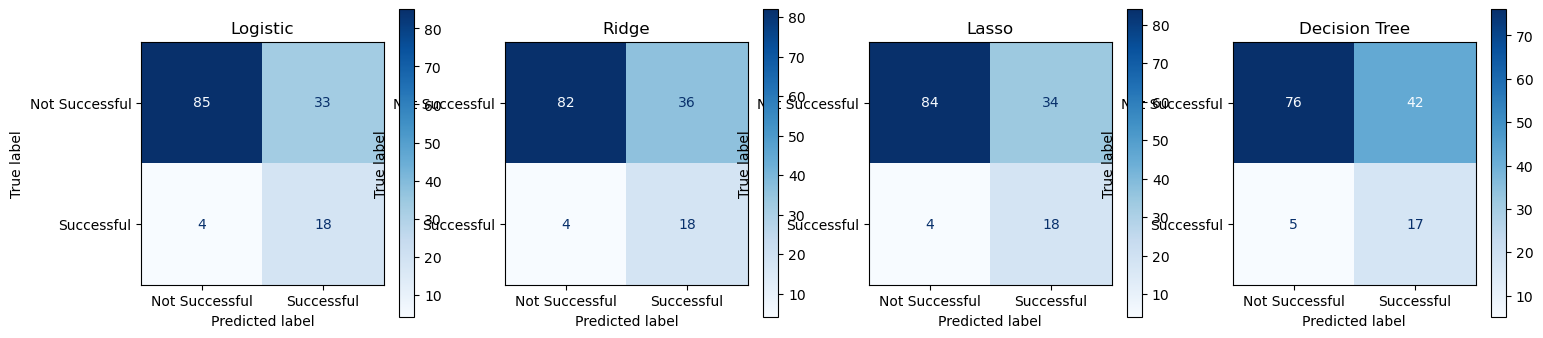

In [ ]:
# 12.5: Confusion Matrix 
# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

models = [
    ('Logistic', logistic.predict(X_test)),
    ('Ridge', ridge.predict(X_test)),
    ('Lasso', lasso.predict(X_test)),
    ('Decision Tree', y_pred_best)
]

for ax, (name, y_pred) in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Not Successful', 'Successful'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name)
    
#plt.tight_layout()
plt.show()

## 13. Model Evaluation
We evaluate all models using classification metrics (the correct choice for a binary target).

- **Precision:** of startups flagged as successful, how many actually were?
- **Recall:** of all actually successful startups, how many did the model catch?
- **F1:** mean of precision and recall that penalises extreme imbalance between the two.

In [ ]:
from sklearn.metrics import classification_report

for name, model in [('Logistic', logistic), ('Ridge', ridge), ('Lasso', lasso)]:
    y_pred_class = (model.predict(X_test))
    print(f' {name}:')
    print(classification_report(y_test, y_pred_class, target_names=['Not Successful', 'Successful']))

 Logistic:
                precision    recall  f1-score   support

Not Successful       0.96      0.72      0.82       118
    Successful       0.35      0.82      0.49        22

      accuracy                           0.74       140
     macro avg       0.65      0.77      0.66       140
  weighted avg       0.86      0.74      0.77       140

 Ridge:
                precision    recall  f1-score   support

Not Successful       0.95      0.69      0.80       118
    Successful       0.33      0.82      0.47        22

      accuracy                           0.71       140
     macro avg       0.64      0.76      0.64       140
  weighted avg       0.86      0.71      0.75       140

 Lasso:
                precision    recall  f1-score   support

Not Successful       0.95      0.71      0.82       118
    Successful       0.35      0.82      0.49        22

      accuracy                           0.73       140
     macro avg       0.65      0.77      0.65       140
  weighted av

Exception ignored in: <function ResourceTracker.__del__ at 0x106d672e0>
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107eeb2e0>
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Applications/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__

In [ ]:
# Summary comparison table 
rows = []
for name, model in [('Logistic ', logistic), ('Ridge ', ridge), ('Lasso ', lasso)]:
    y_pred = model.predict(X_test)
    rows.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0)
    })

rows.append({
    'Model': 'Decision Tree',
    'Precision': precision_score(y_test, y_pred_best, zero_division=0),
    'Recall': recall_score(y_test, y_pred_best, zero_division=0),
    'F1': f1_score(y_test, y_pred_best, zero_division=0)
})

display(pd.DataFrame(rows).set_index('Model').round(3))

,Precision,Recall,F1
Model,,,
Logistic,0.353,0.818,0.493
Ridge,0.333,0.818,0.474
Lasso,0.346,0.818,0.486
Decision Tree,0.288,0.773,0.420


## 14. Interpretation of Results

### Feature importance

In [34]:
# Feature importance by absolute coefficient
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Logistic': np.abs(logistic.coef_[0]),
    'Ridge':    np.abs(ridge.coef_[0]),
    'Lasso':    np.abs(lasso.coef_[0])
}).sort_values(by='Lasso', ascending=False)

display(importance.set_index('Feature').round(4))

,Logistic,Ridge,Lasso
Feature,,,
has_twitter,2.2399,1.9262,2.0061
tweet_length,1.3689,1.1081,1.1859
quoted_ratio,0.2648,0.2472,0.2414
engagement_ratio,0.0397,0.0414,0.1014
reply_rate,0.0896,0.0989,0.0807
retweeted_ratio,0.0909,0.0303,0.0349
retweet_ratio,0.0758,0.0720,0.0000
tweet_rate,0.0229,0.0092,0.0000


In [35]:
# 2. Sparsity Analysis
sparsity = importance[importance['Lasso'] == 0]
display(sparsity)

,Feature,Logistic,Ridge,Lasso
1,retweet_ratio,0.075849,0.071999,0.0
4,tweet_rate,0.022888,0.009209,0.0


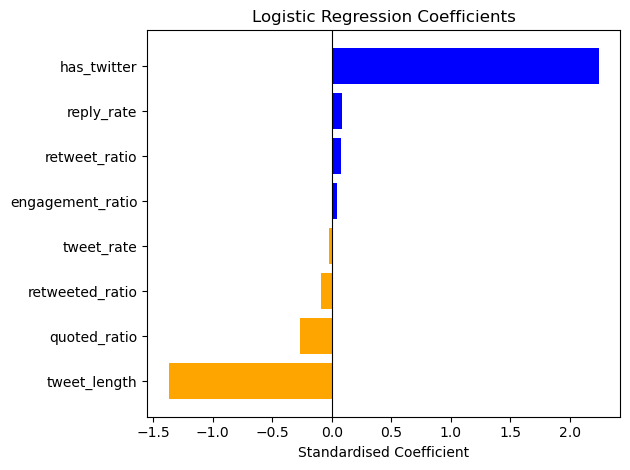

In [ ]:
# Coefficient plot for Logistic model (standardised to be comparable)
coef_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coefficient': logistic.coef_[0]
}).sort_values('Coefficient')

colors = ['blue' if c > 0 else 'orange' for c in coef_df['Coefficient']]

fig, ax = plt.subplots()
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()


### Coefficient interpretation
Since all features are standardised, coefficients are directly comparable:

The has_twitter is the most influencial feature in the  model. Retweet ratio is also positive, startups that get retweeted by others more tend to succeed, which makes sense since it is signal of real interest. The tweet_length is  the most negative, enforcing the idea that shorter tweets perform better.


Lasso automatically set `retweet_ratio` and `tweet_rate` to zero because their predictive signal overlaps with stronger features like `has_twitter` and `tweet_length` that once those dominant variables are in the model, these two add little extra information and Lasso simply drops them to keep the model simpler.

##  15. Beyond the Confusion Matrix
### 15.1 Business Constants
We define the financial parameters of the fund. These will be used in the profit calculation.

In [ ]:
# Business constraints for the Strategic Fund
GAIN_TP = 2_250_000
LOSS_FP = 250_000
N_SLOTS = 5 

### 15.2 Probability Ranking
We use the **Logistic Regression** model for ranking rather than the Decision Tree because its predicted probabilities are smoother and better-calibrated. Decision trees tend to output probabilities clustered near 0 or 1 (reflecting leaf purity), while Logistic Regression produces a continuous probability score across the full [0, 1] range. Since we need to **rank** all 140 test-set applicants to find the safest top 5, smooth and calibrated confidence scores are essential — a small difference in rank position determines who gets funded.

We extract `predict_proba` for class 1 (Successful) and sort the test set from highest to lowest predicted probability.

In [ ]:
# Probabilities of success from our Logistic model
y_proba_success = logistic.predict_proba(X_test)[:, 1]   # column 1 = class 'Successful'

# Total actual successes in the test set we need for FN calculation in the full EV formula
TOTAL_POSITIVES = int(y_test.sum())

# Rank applicants from highest to lowest predicted probability, keeping company names
eval_df = pd.DataFrame({
    'name':         df.loc[y_test.index, 'name'].values,
    'actual':       y_test.values,
    'prob_success': y_proba_success
}).sort_values('prob_success', ascending=False).reset_index(drop=True)

eval_df['is_tp']  = (eval_df['actual'] == 1).astype(int) #funded success = TP
eval_df['is_fp']  = (eval_df['actual'] == 0).astype(int) # funded failure = FP
eval_df['cum_tp'] = eval_df['is_tp'].cumsum()
eval_df['cum_fp'] = eval_df['is_fp'].cumsum()
eval_df['cum_fn'] = TOTAL_POSITIVES - eval_df['cum_tp'] #missed successes = FN

eval_df.head()

,name,actual,prob_success,is_tp,is_fp,cum_tp,cum_fp,cum_fn
0,SILK BIOMATERIALS SRL,1,0.880451,1,0,1,0,21
1,VIDEOAGENCY SAS,1,0.864672,1,0,2,0,20
2,INDOORATLAS OY,1,0.827416,1,0,3,0,19
3,COMBIGENE AB,0,0.819856,0,1,3,1,19
4,SMARTER GRID SOLUTIONS LTD,1,0.808233,1,0,4,1,18


### 15.3 The Profit Curve
This curve answers: *if we funded the top X% of applicants, how much money would the fund make?*
$$EV = (n_{TP} \times 2{,}250{,}000) - (n_{FP} \times 250{,}000) - (n_{FN}\times 2{,}250{,}000)$$

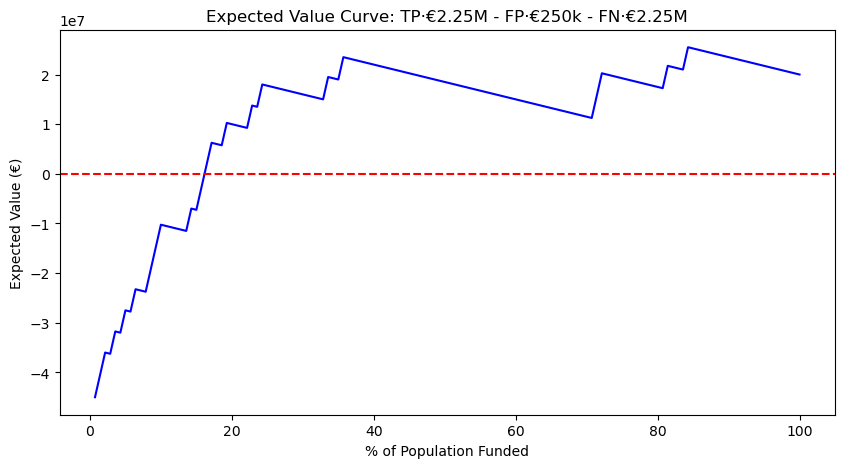

Peak EV at 84.3% of applicants at €25,500,000


In [46]:

eval_df['ev_full'] = (eval_df['cum_tp'] * GAIN_TP) - (eval_df['cum_fp'] * LOSS_FP) - (eval_df['cum_fn'] * GAIN_TP)
eval_df['pop_pct'] = (eval_df.index + 1) / len(eval_df) * 100

plt.figure(figsize=(10, 5))
sns.lineplot(data=eval_df, x='pop_pct', y='ev_full', color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Expected Value Curve: TP·€2.25M - FP·€250k - FN·€2.25M')
plt.xlabel('% of Population Funded')
plt.ylabel('Expected Value (€)')
plt.show()

peak = eval_df.loc[eval_df['ev_full'].idxmax()]
print(f"Peak EV at {peak['pop_pct']:.1f}% of applicants at €{peak['ev_full']:,.0f}")

The curve starts at - €49.5M because missing the 22 good startupscarries a huge opotunity cost. It increases rapidly on the left because the highest-confidence applicants are mostly real successes, and each one we fund adds the +€2.25M TP gain and removes a −€2.25M FN penalty. After a certain point (around 40%) the model starts mixing in failures, so the curve flattens. It peaks at 84.3% at €25.500 M, where our nodel would have found the last succesfull startup and beyound that it would only be losses.

Investing in only 5 startups would put us at the begining (left) of the curve, since our €1.25M capital only covers 5 tickets of €250k.

**About the formula used.** Strictly speaking, for any single startup only one of TP or FN can happen, either we fund the unicorn or we miss it, never both. So adding the FN penalty on top of the TP gain is counting the same event twice7. We still use the formula as the business case defines it because it makes the asymmetry very visible; each "save" looks like +€4.5M of impact(+2.25-(-2.25)), a simpler explanation would be: *funding a unicorn earns €2.25M and avoids the €2.25M opportunity cost of missing it, even if those are the same event.* 

### 15.3.1 Funded-only Profit Curve
To see the actual cash flow of the investments, we will now plot the expected profit to % funded, which only countsthe actual money output:
$$EV = (n_{TP} \times 2.25M) - (n_{FP} \times 250k)$$

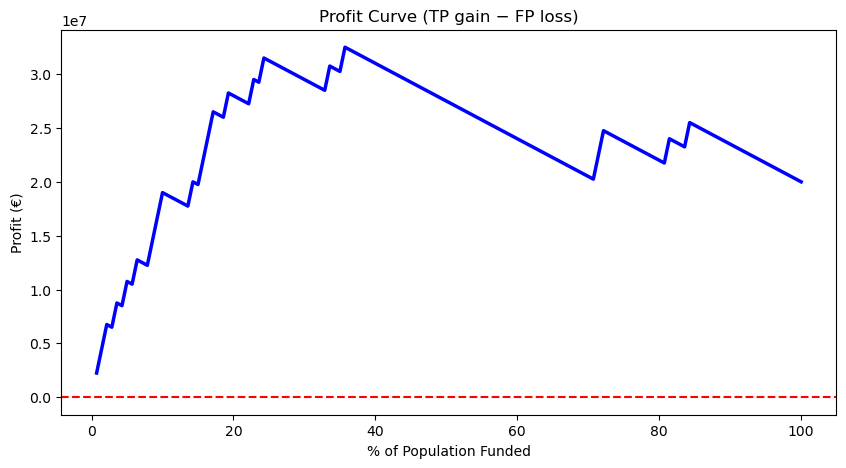

Peak EV at 35.7% of applicants at €32,500,000


In [47]:
# Tutorial-style: only TP gain and FP loss (no FN cost)

eval_df['ev_funded'] = (eval_df['cum_tp'] * GAIN_TP) - (eval_df['cum_fp'] * LOSS_FP)

plt.figure(figsize=(10, 5))
sns.lineplot(data=eval_df, x='pop_pct', y='ev_funded', color='blue', lw=2.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Profit Curve (TP gain − FP loss)')
plt.xlabel('% of Population Funded')
plt.ylabel('Profit (€)')
plt.show()

peak = eval_df.loc[eval_df['ev_funded'].idxmax()]
print(f"Peak EV at {peak['pop_pct']:.1f}% of applicants at €{peak['ev_funded']:,.0f}")


Unlike the full EV curve above, this one starts at €0 because there is no FN penalty here, so we begin with a clean slate. The curve rises very quickly on the left side because the model first funds the applicants with the highest confidence scores, and most of these are actual successes. Every TP adds +€2.25M, so the value increases fast at the start.

The graph follows an inverted U-shape and reaches a peak at 35.7% of applicants and €32.5M. After that point, adding more applicants starts reducing the total value instead of increasing it. This happens when the probability that the next applicant is actually successful falls below around 10%. 

This is because the loss of €250k compared to the gain of €2.25M creates about a 1:9 ratio (the 10% we pointed out), and that same asymmetry from the business case appears directly in the curve.

The key thing this graph shows is that if we only look at only at cash flow, without considering opportunity cost, the top 5 applicants still produce positive returns.

### 15.4 The ROC Curve & AUC
The ROC curve measures how well the model **separates** successful startups from non-successful ones, regardless of any specific threshold. The AUC summarises this ability in a single number (0.5 = random, 1.0 = perfect).

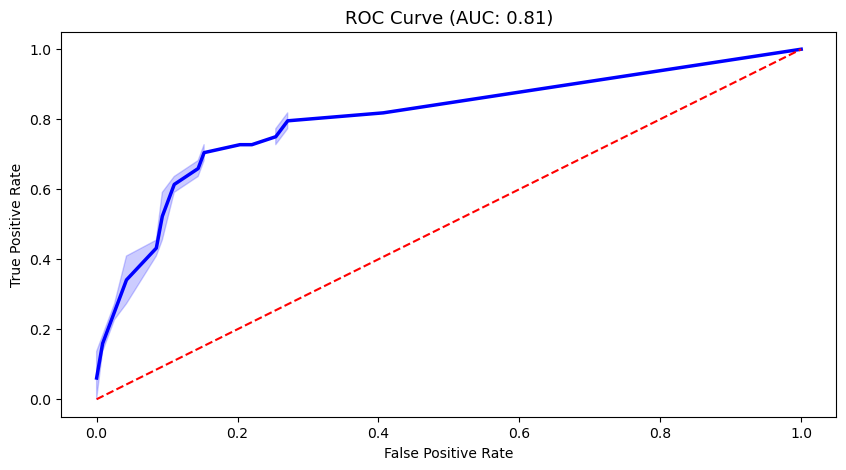

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba_success)
roc_df  = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(10, 5))
sns.lineplot(data=roc_df, x='fpr', y='tpr', color='blue', lw=2.5)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC: {roc_auc:.2f})', fontsize=13)
plt.show()


Our model gets an AUC of 0.81, which is well above the random 0.5 mark. This means that if we pick a random successful startup and a random non-successful one, the model gives a higher score to the successful one 81% of the time. The curve climbs steeply on the left side, reaching 80% true positive rate while still keeping the false positive rate under 30%. 
 This is the shape we want for a 5 ticket fund where we only fund the highest scoring Startups.

### 15.5 The Lift Curve
Lift compares the model's success rate in the top X% against the **base success rate** in the population. A lift of 3x in the top decile means our top picks are 3 times more likely to succeed than a random pick.

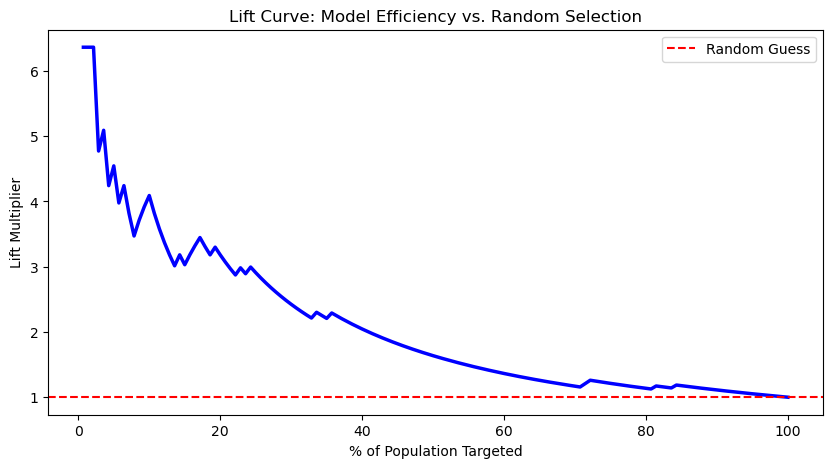

Base success rate: 15.71%
Lift at top 5 startups: 5.09x


In [ ]:
BASE_SUCCESS_RATE = (eval_df['actual'] == 1).mean()


eval_df['lift'] = (eval_df['cum_tp'] / (eval_df.index + 1)) / BASE_SUCCESS_RATE

plt.figure(figsize=(10, 5))
sns.lineplot(data=eval_df, x='pop_pct', y='lift', color='blue', lw=2.5)
plt.axhline(1, color='red', linestyle='--', label='Random Guess')
plt.title('Lift Curve: Model Efficiency vs. Random Selection')
plt.xlabel('% of Population Targeted')
plt.ylabel('Lift Multiplier')
plt.legend()
plt.show()


lift_top5 = eval_df.iloc[N_SLOTS - 1]['lift']
print(f"Base success rate: {BASE_SUCCESS_RATE:.2%}")
print(f"Lift at top {N_SLOTS} startups: {lift_top5:.2f}x")


The lift is highest at the very top of the ranking and decays towards 1.0 (random) as we include more applicants. Since we only need 5 slots, we sit in the **highest-lift region** of the curve, which is the *safety* component of the pitch.

### 15.6 Final Portfolio Selection (the 5 Slots)
Now we pick the actual 5 startups for the €1.25M fund: the 5 applicants in the test set with the highest predicted probability of success.

In [48]:
# Top 5 startups by predicted probability of success
portfolio = eval_df.head(N_SLOTS).copy()

n_winners = (portfolio['actual'] == 1).sum()
n_losers  = (portfolio['actual'] == 0).sum()
fn  = TOTAL_POSITIVES - n_winners  
final_profit = n_winners * GAIN_TP - n_losers * LOSS_FP
ev_full = final_profit - fn * GAIN_TP   

print('--- Portfolio Analysis ---')
print(f"Top {N_SLOTS} avg confidence : {portfolio['prob_success'].mean():.2%}")
print(f"Actual successes in top {N_SLOTS}  : {n_winners}")
print(f"Actual failures in top {N_SLOTS} : {n_losers}")
print(f"Missed unicorns (FN): {fn}")
print(f"Gross fund profit (funded only): €{final_profit:,}")
print(f"Full EV (incl. FN opportunity cost): €{ev_full:,}")

display(portfolio[['name', 'actual', 'prob_success', 'is_tp', 'is_fp', 'cum_tp', 'cum_fp', 'lift']])

--- Portfolio Analysis ---
Top 5 avg confidence : 84.01%
Actual successes in top 5  : 4
Actual failures in top 5 : 1
Missed unicorns (FN): 18
Gross fund profit (funded only): €8,750,000
Full EV (incl. FN opportunity cost): €-31,750,000


,name,actual,prob_success,is_tp,is_fp,cum_tp,cum_fp,lift
0,SILK BIOMATERIALS SRL,1,0.880451,1,0,1,0,6.363636
1,VIDEOAGENCY SAS,1,0.864672,1,0,2,0,6.363636
2,INDOORATLAS OY,1,0.827416,1,0,3,0,6.363636
3,COMBIGENE AB,0,0.819856,0,1,3,1,4.772727
4,SMARTER GRID SOLUTIONS LTD,1,0.808233,1,0,4,1,5.090909


### Final output
Putting the three curves together gives the strategic justification for our 5 picks:

- **Reliability (ROC/AUC).** The Logistic model has an AUC of 0.81, meaning it consistently ranks real successes above failures.
- **Safety (Lift).** At the top 5 startups, the lift is 5.09x. Our shortlist is about 5 times more likely to succeed than a random pick of 5 applicants. 4 out of 5 of our picks were actual successes.
- **Profitability (Profit Curve).** Our 5 slots sit at the leftmost (highest-confidence) end of the curve; not because that is where the peak EV is (the full EV curve peaks around 80%), but because the €1.25M capital constraint forces us to pick only 5. Within that constraint, concentrating on the highest-confidence applicants generated a gross profit of €8,750,000 on €1.25M invested.

Given the 1:9 asymmetry of the case (one missed unicorn costs as much as nine failures), the model behaves exactly as the strategy requires: high recall on the top-confidence band, with the bulk of the principal concentrated in the safest applicants.

## 16. Final Summary
1. **`has_twitter` is the strongest predictor.** Having a Twitter presence alone explains a large part of the variance in startup success, consistent with our EDA finding of a 4× success rate gap.

2. **Engagement quality matters more than quantity.** Rate and ratio variables (reply_rate, retweet_ratio, engagement_ratio) are stronger predictors than raw counts, which is why raw counts were excluded following the EDA recommendation.

3. **Lasso confirms feature relevance.** It confirms that most features are genuinely informative but it drops retweet_ratio and tweet_rate, classifying them as not relevant once the stronger predictors are in the model."

4. **Strategic evaluation supports the portfolio.** The Profit, ROC and Lift curves show that our top-5 selection sits at the safest end of the ranking, with a lift well above random and an AUC that confirms the model is a reliable filter for risk. In a 1:9 asymmetric setting, this is exactly where the fund should be operating.
